# Reproduction of a Reference-Free Molecular Feedback Controller

**Paper:** *A Reference-Free Molecular Feedback Controller for Inducing Sustained Oscillations in Gene Regulatory Networks*  
**Authors:** Frank Britto Bisso, Sergio Rengifo-Lozano, Subham Dey, Guy-Bart Stan, Christian Cuba Samaniego

## Objective

This notebook reproduces the numerical experiments associated with **Figs. 2 and 3** and the higher-dimensional **negative-feedback (NF) oscillator case study in Fig. 4**.

The central question is whether the proposed incoherent feedforward-loop (IFFL) molecular controller can destabilize a stable self-inhibiting gene and generate sustained oscillations.

The notebook follows the published dimensionless ODEs, parameter values, perturbation values, and figure descriptions as closely as possible.

> **Reproduction note:** the paper does not provide the original simulation source code. Therefore, exact solver settings, sampling density, and some plotting details are reconstructed here rather than copied from an author-provided implementation.

## 1. Imports

NumPy is used for numerical calculations, SciPy for ODE integration/root finding/peak detection, and Matplotlib for the figures.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import root
from scipy.signal import find_peaks

plt.rcParams["figure.dpi"] = 120

## 2. Self-inhibiting gene + IFFL controller

The paper gives the dimensionless closed-loop model in Eqs. (4)–(7):

\[
\frac{d\hat u_1}{d\tau}
=\hat k\hat x-\hat u_1-\hat\gamma\hat u_1\hat u_2
\]

\[
\frac{d\hat u_2}{d\tau}
=\hat\rho\frac{1}{1+\hat y^m}
-\hat u_2-\hat\gamma\hat u_1\hat u_2
\]

\[
\frac{d\hat x}{d\tau}
=\hat\theta\frac{1}{1+\hat y^m}-\hat x
\]

\[
\frac{d\hat y}{d\tau}
=\hat\alpha\frac{1}{1+\hat y^m}
-\hat y+\hat\beta\hat u_1.
\]

State order:

\[
[\hat u_1,\hat u_2,\hat x,\hat y].
\]

The controller branch ratio is

\[
\hat r=\frac{\hat\rho}{\hat k\hat\theta}.
\]

For the nominal Fig. 2/3 parameters:

\[
\hat\alpha=4,\quad
\hat\beta=4,\quad
\hat k=2.5,\quad
\hat\theta=10,\quad
\hat\rho=25,\quad
\hat\gamma=100,\quad
m=1.
\]

Thus \(\hat r=1\).

In [4]:
params = {
    "alpha": 4.0,
    "beta": 4.0,
    "k": 2.5,
    "theta": 10.0,
    "rho": 25.0,
    "gamma": 100.0,
    "m": 1.0,
}

params

{'alpha': 4.0,
 'beta': 4.0,
 'k': 2.5,
 'theta': 10.0,
 'rho': 25.0,
 'gamma': 100.0,
 'm': 1.0}

## 3. Closed-loop ODE

Direct implementation of Eqs. (4)–(7).

In [5]:
def closed_loop_ode(tau, state, params):
    u1, u2, x, y = state

    alpha = params["alpha"]
    beta = params["beta"]
    k = params["k"]
    theta = params["theta"]
    rho = params["rho"]
    gamma = params["gamma"]
    m = params["m"]

    hill = 1.0 / (1.0 + y**m)

    du1_dt = k * x - u1 - gamma * u1 * u2
    du2_dt = rho * hill - u2 - gamma * u1 * u2
    dx_dt = theta * hill - x
    dy_dt = alpha * hill - y + beta * u1

    return np.array([du1_dt, du2_dt, dx_dt, dy_dt])

## 4. Initial conditions

The Fig. 2 simulations are initialized from zero.

In [6]:
initial_conditions = np.zeros(4)

print("Initial state:", initial_conditions)
print("Initial derivatives:", closed_loop_ode(0.0, initial_conditions, params))

Initial state: [0. 0. 0. 0.]
Initial derivatives: [ 0. 25. 10.  4.]


## 5. Reusable simulation and analysis functions

Amplitude is measured from the latter part of the trajectory to reduce the effect of the initial transient. Period is measured as the mean time between adjacent peaks, matching the definition used for Fig. 3C.

In [7]:
def simulate_closed_loop(params, t_end=200.0, n_points=4000, y0=None):
    if y0 is None:
        y0 = initial_conditions.copy()

    t_eval = np.linspace(0.0, t_end, n_points)

    return solve_ivp(
        fun=lambda tau, state: closed_loop_ode(tau, state, params),
        t_span=(0.0, t_end),
        y0=y0,
        t_eval=t_eval,
        rtol=1e-8,
        atol=1e-10,
        method="RK45"
    )


def calculate_rhat(params):
    return params["rho"] / (params["k"] * params["theta"])


def gain_threshold(params):
    # Eq. (27): beta*k*theta >= 16*alpha
    return 16.0 * params["alpha"] / (params["k"] * params["theta"])


def steady_state_amplitude(tau, signal, start_fraction=0.5):
    start = int(len(signal) * start_fraction)
    signal_ss = signal[start:]
    return np.max(signal_ss) - np.min(signal_ss)


def peak_period(tau, signal, start_fraction=0.5, min_peak_distance=100):
    start = int(len(signal) * start_fraction)
    tau_ss = tau[start:]
    signal_ss = signal[start:]

    peaks, _ = find_peaks(signal_ss, distance=min_peak_distance)

    if len(peaks) < 2:
        return np.nan

    return np.mean(np.diff(tau_ss[peaks]))


def numerical_jacobian(func, state, params, eps=1e-6):
    state = np.asarray(state, dtype=float)
    n = len(state)
    J = np.zeros((n, n))

    for j in range(n):
        state_plus = state.copy()
        state_minus = state.copy()

        state_plus[j] += eps
        state_minus[j] -= eps

        f_plus = np.asarray(func(0.0, state_plus, params), dtype=float)
        f_minus = np.asarray(func(0.0, state_minus, params), dtype=float)

        J[:, j] = (f_plus - f_minus) / (2.0 * eps)

    return J


def find_equilibrium(params, initial_guess=None):
    if initial_guess is None:
        initial_guess = np.array([0.25, 0.25, 3.0, 2.3])

    result = root(
        lambda state: closed_loop_ode(0.0, state, params),
        initial_guess
    )

    if not result.success:
        return None

    return result.x


def classify_equilibrium(params, initial_guess=None):
    equilibrium = find_equilibrium(params, initial_guess)

    if equilibrium is None:
        return None, None, None

    J = numerical_jacobian(
        closed_loop_ode,
        equilibrium,
        params
    )

    eigenvalues = np.linalg.eigvals(J)
    real_parts = np.real(eigenvalues)

    if np.all(real_parts < 0):
        classification = 0
    else:
        unstable_complex = any(
            (abs(np.imag(ev)) > 1e-8) and (np.real(ev) > 0)
            for ev in eigenvalues
        )
        classification = 2 if unstable_complex else 1

    return classification, equilibrium, eigenvalues

## 6. Baseline simulation

First verify that the nominal closed-loop system oscillates.

In [8]:
solution = simulate_closed_loop(params)

tau = solution.t
u1 = solution.y[0]
u2 = solution.y[1]
x = solution.y[2]
y = solution.y[3]

print("Solver successful:", solution.success)
print("Number of time points:", len(tau))
print("r_hat =", calculate_rhat(params))
print("Gain threshold =", gain_threshold(params))

Solver successful: True
Number of time points: 4000
r_hat = 1.0
Gain threshold = 2.56


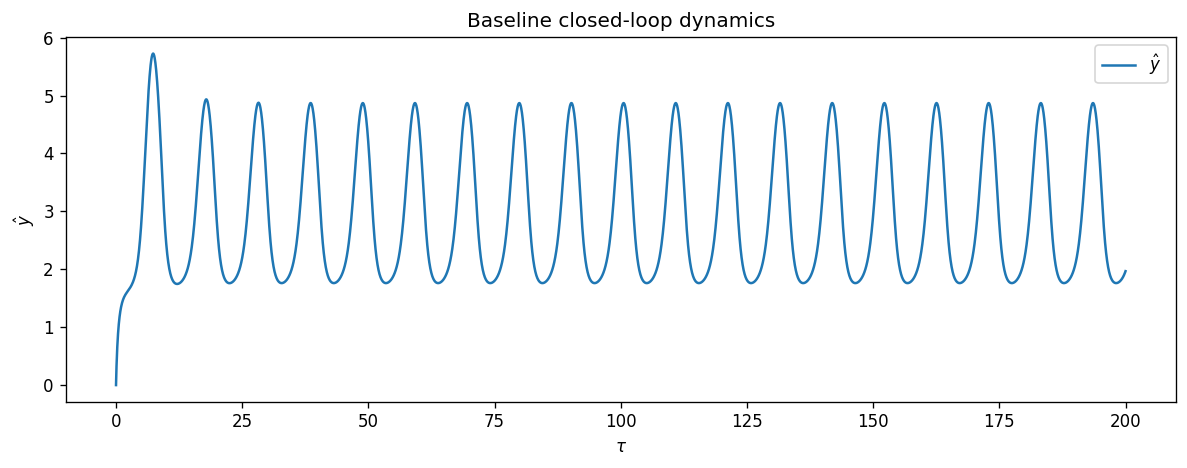

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(tau, y, label=r"$\hat y$")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$\hat y$")
plt.title("Baseline closed-loop dynamics")
plt.legend()
plt.tight_layout()
plt.show()

# Figure 2A — Controller-induced sustained oscillations

Compare the isolated self-inhibiting gene with the IFFL-controlled system from zero initial conditions.

In [10]:
def isolated_gene_ode(tau, state, params):
    y = state[0]
    hill = 1.0 / (1.0 + y**params["m"])
    return np.array([params["alpha"] * hill - y])


isolated_solution = solve_ivp(
    fun=lambda tau, state: isolated_gene_ode(tau, state, params),
    t_span=(0.0, 200.0),
    y0=[0.0],
    t_eval=np.linspace(0.0, 200.0, 4000),
    rtol=1e-8,
    atol=1e-10
)

y_isolated = isolated_solution.y[0]

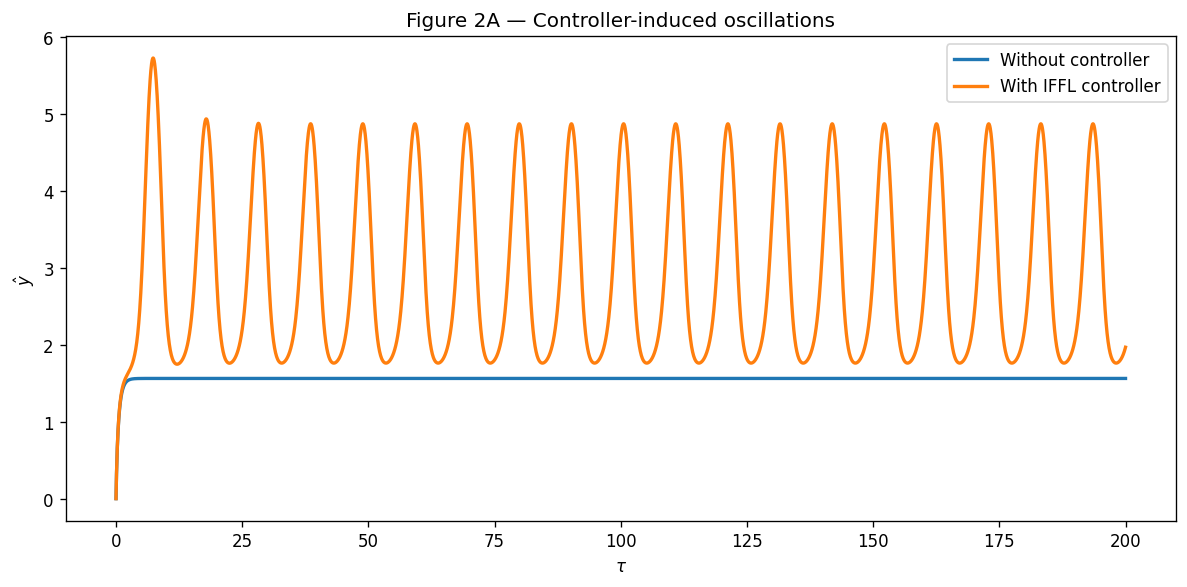

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(
    isolated_solution.t,
    y_isolated,
    linewidth=2,
    label="Without controller"
)

plt.plot(
    tau,
    y,
    linewidth=2,
    label="With IFFL controller"
)

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\hat y$")
plt.title("Figure 2A — Controller-induced oscillations")
plt.legend()
plt.tight_layout()
plt.show()

# Figure 2B — Phase portrait

The paper shows the limit cycle in the \((\hat y,\hat u_1)\) plane and marks the closed-loop equilibrium.

The full system remains four-dimensional; the phase portrait is a projection onto two variables.

In [12]:
equilibrium = find_equilibrium(params)

print("Equilibrium [u1, u2, x, y]:")
print(equilibrium)

J_nominal = numerical_jacobian(
    closed_loop_ode,
    equilibrium,
    params
)

eigenvalues_nominal = np.linalg.eigvals(J_nominal)

print("\nNominal 4x4 Jacobian eigenvalues:")
for ev in eigenvalues_nominal:
    print(ev)

Equilibrium [u1, u2, x, y]:
[0.27046947 0.27046947 3.03433712 2.29561272]

Nominal 4x4 Jacobian eigenvalues:
(-55.00952406555729+0j)
(-3.729551849781008+0j)
(0.13844709971841135+0.6270170602365461j)
(0.13844709971841135-0.6270170602365461j)


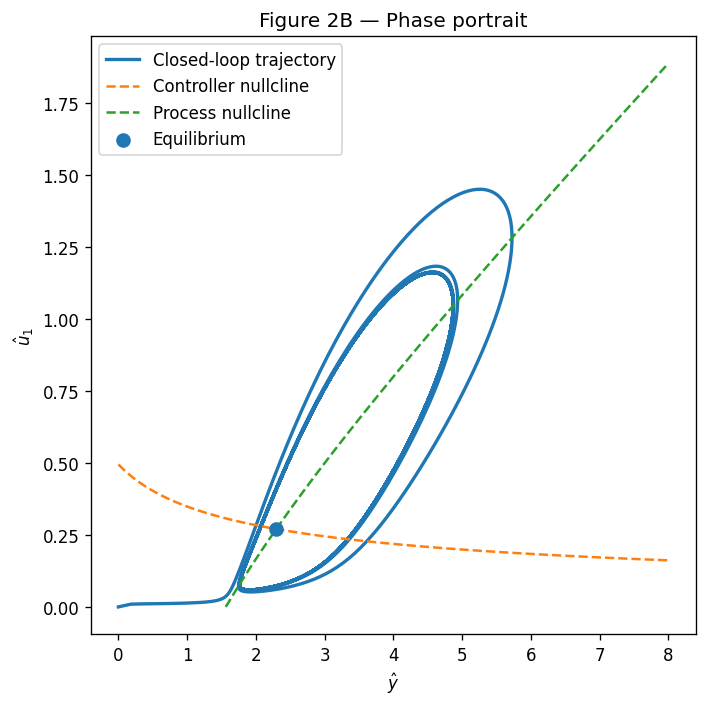

In [13]:
# Projected nullclines for the (y, u1) plane.
# These are constructed from the corresponding steady-state relations.

y_grid = np.linspace(0.0, 8.0, 1000)
hill_grid = 1.0 / (1.0 + y_grid**params["m"])

x_null = params["theta"] * hill_grid

u1_controller_null = np.full_like(y_grid, np.nan)

for i, (yy, xx, hh) in enumerate(zip(y_grid, x_null, hill_grid)):

    def controller_nullcline(u1_value):
        u2_value = (
            params["rho"] * hh
            / (1.0 + params["gamma"] * u1_value)
        )
        return (
            params["k"] * xx
            - u1_value
            - params["gamma"] * u1_value * u2_value
        )

    rr = root(
        lambda q: controller_nullcline(float(q[0])),
        [0.2]
    )

    if rr.success and rr.x[0] >= 0:
        u1_controller_null[i] = rr.x[0]

u1_process_null = (
    y_grid - params["alpha"] * hill_grid
) / params["beta"]

u1_process_null[u1_process_null < 0] = np.nan


plt.figure(figsize=(6, 6))

plt.plot(
    y,
    u1,
    linewidth=2,
    label="Closed-loop trajectory"
)

plt.plot(
    y_grid,
    u1_controller_null,
    linestyle="--",
    linewidth=1.5,
    label="Controller nullcline"
)

plt.plot(
    y_grid,
    u1_process_null,
    linestyle="--",
    linewidth=1.5,
    label="Process nullcline"
)

plt.scatter(
    equilibrium[3],
    equilibrium[0],
    s=60,
    zorder=5,
    label="Equilibrium"
)

plt.xlabel(r"$\hat y$")
plt.ylabel(r"$\hat u_1$")
plt.title("Figure 2B — Phase portrait")
plt.legend()
plt.tight_layout()
plt.show()

# Figure 2C — Numerical stability map

The paper varies \((\hat\alpha,\hat\beta)\) while holding

\[
\hat r=1,\qquad \hat\gamma=100,
\]

and classifies each point from the eigenvalues of the **full 4 × 4 Jacobian**.

The analytical boundary is Eq. (27):

\[
\hat\beta\hat k\hat\theta=16\hat\alpha.
\]

For \(\hat k=2.5\) and \(\hat\theta=10\),

\[
\hat\beta=0.64\hat\alpha.
\]

In [14]:
alpha_values_2c = np.linspace(0.5, 6.0, 70)
beta_values_2c = np.linspace(0.5, 6.0, 70)

classification_map = np.full(
    (len(beta_values_2c), len(alpha_values_2c)),
    np.nan
)

for i, beta_value in enumerate(beta_values_2c):
    for j, alpha_value in enumerate(alpha_values_2c):

        p_test = params.copy()
        p_test["alpha"] = alpha_value
        p_test["beta"] = beta_value

        # Enforce r_hat = 1.
        p_test["rho"] = p_test["k"] * p_test["theta"]
        p_test["gamma"] = 100.0

        classification, _, _ = classify_equilibrium(
            p_test,
            initial_guess=equilibrium
        )

        if classification is not None:
            classification_map[i, j] = classification

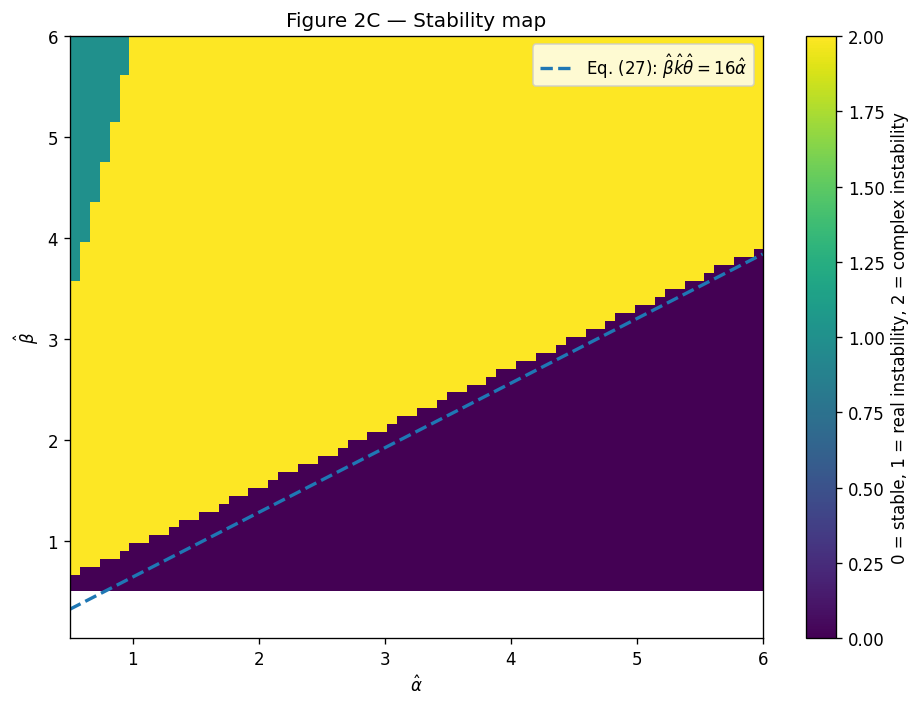

In [15]:
plt.figure(figsize=(8, 6))

plt.imshow(
    classification_map,
    origin="lower",
    extent=[
        alpha_values_2c.min(),
        alpha_values_2c.max(),
        beta_values_2c.min(),
        beta_values_2c.max()
    ],
    aspect="auto",
    interpolation="nearest"
)

beta_boundary_2c = (
    16.0
    * alpha_values_2c
    / (params["k"] * params["theta"])
)

plt.plot(
    alpha_values_2c,
    beta_boundary_2c,
    linestyle="--",
    linewidth=2,
    label=r"Eq. (27): $\hat\beta\hat k\hat\theta=16\hat\alpha$"
)

plt.xlabel(r"$\hat\alpha$")
plt.ylabel(r"$\hat\beta$")
plt.title("Figure 2C — Stability map")

plt.colorbar(
    label="0 = stable, 1 = real instability, 2 = complex instability"
)

plt.legend()
plt.tight_layout()
plt.show()

## Figure 2C — Representative numerical check

The two points below demonstrate how the eigenvalues change as the gain crosses the analytical threshold.

In [16]:
for alpha_value, beta_value in [(4.0, 2.0), (4.0, 4.0)]:

    p_test = params.copy()
    p_test["alpha"] = alpha_value
    p_test["beta"] = beta_value
    p_test["rho"] = p_test["k"] * p_test["theta"]

    classification, eq, eigs = classify_equilibrium(p_test)

    print(
        f"alpha={alpha_value:.1f}, "
        f"beta={beta_value:.1f}, "
        f"threshold={gain_threshold(p_test):.3f}"
    )
    print("classification:", classification)
    print("equilibrium:", eq)
    print("eigenvalues:", eigs)
    print()

alpha=4.0, beta=2.0, threshold=2.560
classification: 0
equilibrium: [0.28684439 0.28684439 3.40592593 1.93605915]
eigenvalues: [-58.31871391+0.j          -3.30144246+0.j
  -0.10636749+0.68017576j  -0.10636749-0.68017576j]

alpha=4.0, beta=4.0, threshold=2.560
classification: 2
equilibrium: [0.27046947 0.27046947 3.03433712 2.29561272]
eigenvalues: [-55.00952407+0.j          -3.72955185+0.j
   0.1384471 +0.62701706j   0.1384471 -0.62701706j]



# Figure 2D — Effect of \(\hat r\)

The paper uses

\[
\hat r=\{0.8,0.9,1.0,1.1\}
\]

at fixed \(\hat\alpha=4\), varying \(\hat\rho\) through

\[
\hat r=\frac{\hat\rho}{\hat k\hat\theta}.
\]

The reported behavior is sustained oscillation for \(\hat r\le1\), with decreasing amplitude as \(\hat r\to1\), and convergence to the isolated-gene steady state for \(\hat r=1.1\).

<>:30: SyntaxWarning: invalid escape sequence '\h'
<>:30: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1962/2240525796.py:30: SyntaxWarning: invalid escape sequence '\h'
  plt.title("Figure 2D — Effect of $\hat r$")


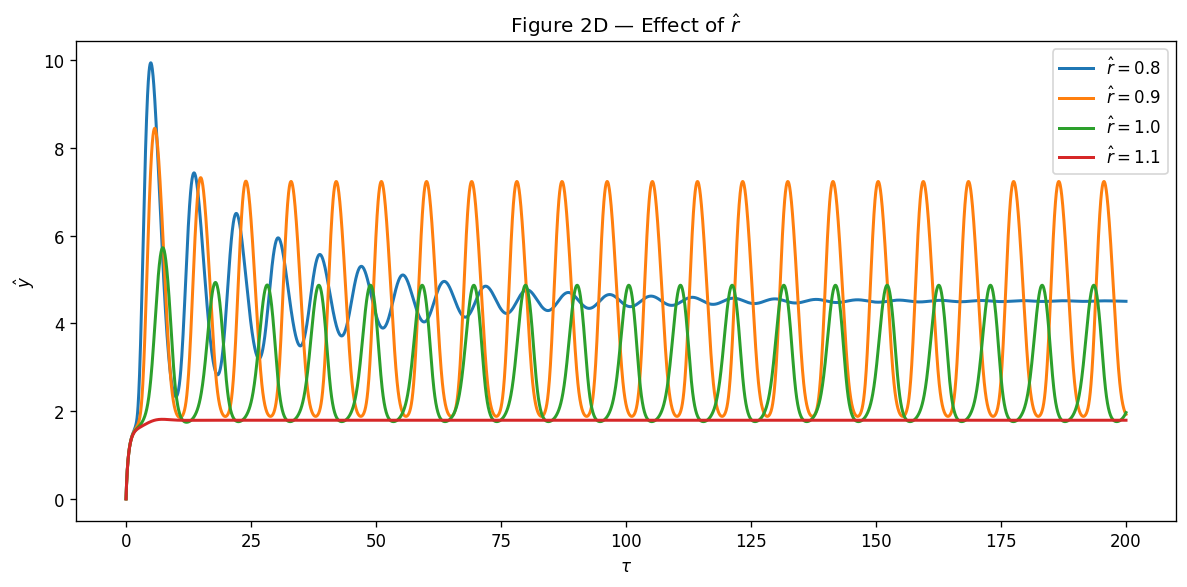

In [17]:
r_values = [0.8, 0.9, 1.0, 1.1]

plt.figure(figsize=(10, 5))

for r_value in r_values:

    p_test = params.copy()
    p_test["alpha"] = 4.0
    p_test["rho"] = (
        r_value
        * p_test["k"]
        * p_test["theta"]
    )

    sol = simulate_closed_loop(
        p_test,
        t_end=200,
        n_points=4000
    )

    plt.plot(
        sol.t,
        sol.y[3],
        linewidth=1.8,
        label=fr"$\hat r={r_value}$"
    )

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\hat y$")
plt.title("Figure 2D — Effect of $\hat r$")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
print("Figure 2D quantitative summary")

for r_value in r_values:

    p_test = params.copy()
    p_test["alpha"] = 4.0
    p_test["rho"] = (
        r_value
        * p_test["k"]
        * p_test["theta"]
    )

    sol = simulate_closed_loop(p_test)

    A = steady_state_amplitude(sol.t, sol.y[3])
    T = peak_period(sol.t, sol.y[3])

    print(
        f"r_hat={r_value:.1f} | "
        f"amplitude={A:.4f} | "
        f"period={T:.4f}"
    )

Figure 2D quantitative summary
r_hat=0.8 | amplitude=0.2408 | period=8.2612
r_hat=0.9 | amplitude=5.3541 | period=9.0323
r_hat=1.0 | amplitude=3.1085 | period=10.3304
r_hat=1.1 | amplitude=0.0000 | period=7.7978


# Figure 2E — Finite sequestration

The paper varies

\[
\hat\gamma=\{1,10,100,1000\}
\]

around the nominal value while keeping the remaining Fig. 2 parameters fixed.

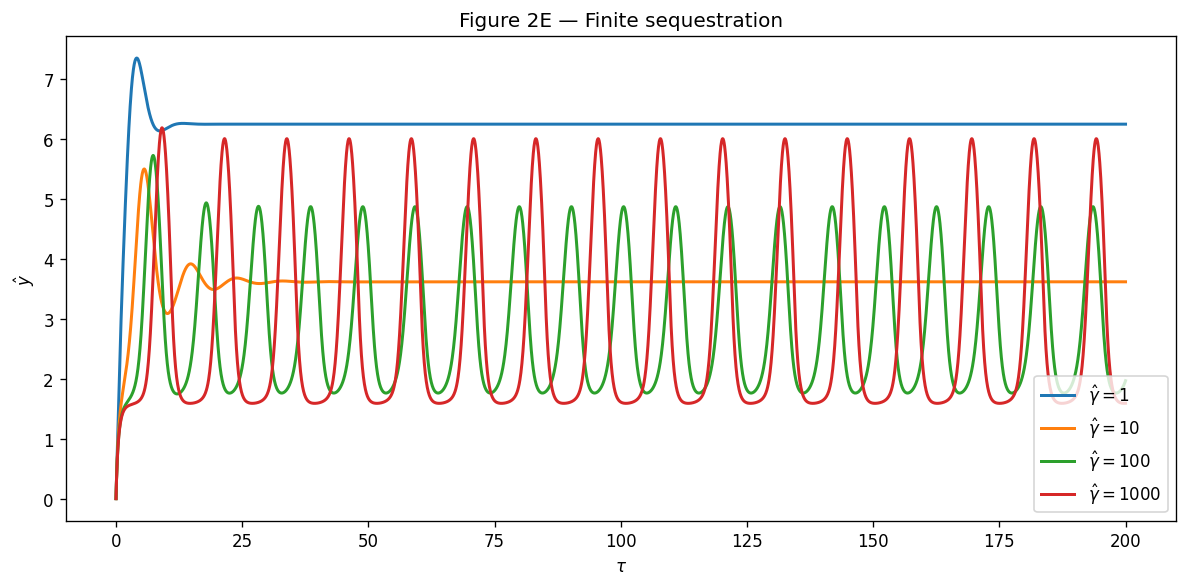

In [19]:
gamma_values = [1, 10, 100, 1000]

plt.figure(figsize=(10, 5))

for gamma_value in gamma_values:

    p_test = params.copy()
    p_test["gamma"] = gamma_value

    sol = simulate_closed_loop(
        p_test,
        t_end=200,
        n_points=4000
    )

    plt.plot(
        sol.t,
        sol.y[3],
        linewidth=1.8,
        label=fr"$\hat\gamma={gamma_value}$"
    )

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\hat y$")
plt.title("Figure 2E — Finite sequestration")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
print("Figure 2E quantitative summary")

for gamma_value in gamma_values:

    p_test = params.copy()
    p_test["gamma"] = gamma_value

    sol = simulate_closed_loop(p_test)

    A = steady_state_amplitude(sol.t, sol.y[3])
    T = peak_period(sol.t, sol.y[3])

    print(
        f"gamma={gamma_value:4d} | "
        f"amplitude={A:.4f} | "
        f"period={T:.4f}"
    )

Figure 2E quantitative summary
gamma=   1 | amplitude=0.0000 | period=7.4557
gamma=  10 | amplitude=0.0000 | period=7.5477
gamma= 100 | amplitude=3.1085 | period=10.3304
gamma=1000 | amplitude=4.4143 | period=12.3317


# Figure 3A — Adaptation to sequential perturbations

The published Fig. 3A uses:

- perturbations at \(\tau=40,80,120\);
- fixed \(\hat\beta=5\);
- at \(\tau=40\): \(2\times\hat\alpha\);
- at \(\tau=80\): \(3\times m\);
- at \(\tau=120\): \(3\times\hat\alpha\).

Starting from \(\hat\alpha=4,m=1\), the four intervals are therefore:

| Interval | \(\hat\alpha\) | \(m\) |
|---|---:|---:|
| 0–40 | 4 | 1 |
| 40–80 | 8 | 1 |
| 80–120 | 8 | 3 |
| 120–160 | 12 | 3 |

In [21]:
def simulate_sequential_self_inhibiting(
    base_params,
    schedules,
    perturbation_times=(40, 80, 120),
    final_time=160,
    beta=5.0,
    points_per_interval=1000
):
    boundaries = [0.0, *perturbation_times, final_time]

    state = np.zeros(4)
    all_t = []
    all_states = []

    for i in range(len(boundaries) - 1):

        p = base_params.copy()
        p.update(schedules[i])
        p["beta"] = beta

        t0 = boundaries[i]
        t1 = boundaries[i + 1]

        t_eval = np.linspace(t0, t1, points_per_interval)

        sol = solve_ivp(
            fun=lambda tau, state:
                closed_loop_ode(tau, state, p),
            t_span=(t0, t1),
            y0=state,
            t_eval=t_eval,
            rtol=1e-8,
            atol=1e-10
        )

        if i == 0:
            all_t.extend(sol.t)
            all_states.extend(sol.y.T)
        else:
            all_t.extend(sol.t[1:])
            all_states.extend(sol.y[:, 1:].T)

        state = sol.y[:, -1]

    return np.array(all_t), np.array(all_states)


schedules_3a = [
    {"alpha": 4.0, "m": 1.0},
    {"alpha": 8.0, "m": 1.0},
    {"alpha": 8.0, "m": 3.0},
    {"alpha": 12.0, "m": 3.0},
]

tau_3a, states_3a = simulate_sequential_self_inhibiting(
    params,
    schedules_3a,
    beta=5.0
)

In [22]:
def simulate_sequential_isolated(
    base_params,
    schedules,
    perturbation_times=(40, 80, 120),
    final_time=160,
    points_per_interval=1000
):
    boundaries = [0.0, *perturbation_times, final_time]

    state = np.array([0.0])
    all_t = []
    all_y = []

    for i in range(len(boundaries) - 1):

        p = base_params.copy()
        p.update(schedules[i])

        t0 = boundaries[i]
        t1 = boundaries[i + 1]

        t_eval = np.linspace(t0, t1, points_per_interval)

        sol = solve_ivp(
            fun=lambda tau, state:
                isolated_gene_ode(tau, state, p),
            t_span=(t0, t1),
            y0=state,
            t_eval=t_eval,
            rtol=1e-8,
            atol=1e-10
        )

        if i == 0:
            all_t.extend(sol.t)
            all_y.extend(sol.y[0])
        else:
            all_t.extend(sol.t[1:])
            all_y.extend(sol.y[0, 1:])

        state = sol.y[:, -1]

    return np.array(all_t), np.array(all_y)


tau_3a_uncontrolled, y_3a_uncontrolled =     simulate_sequential_isolated(params, schedules_3a)

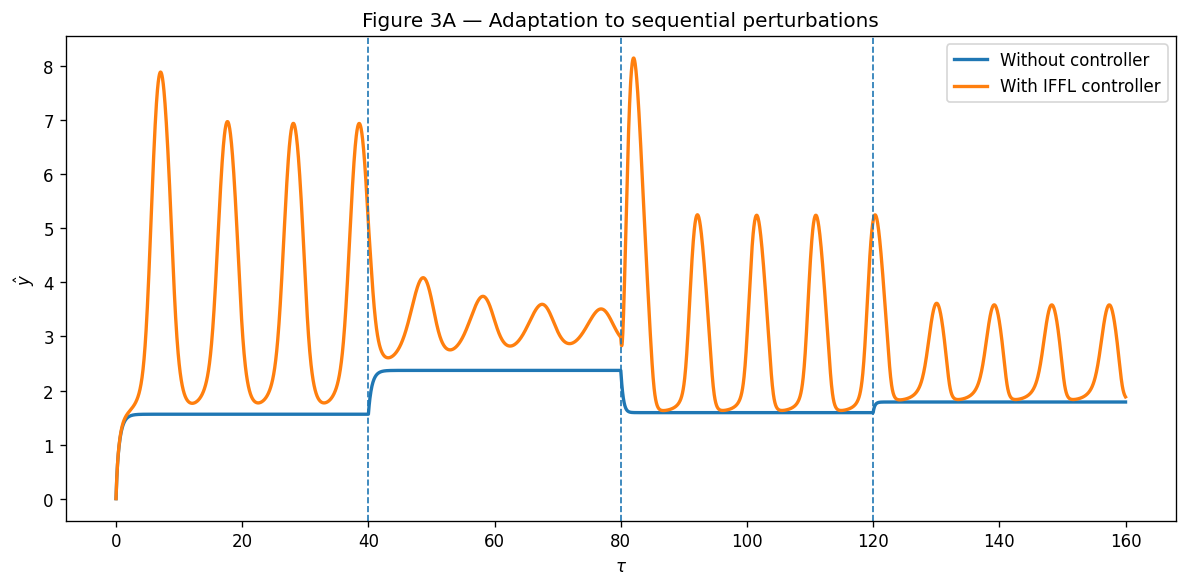

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(
    tau_3a_uncontrolled,
    y_3a_uncontrolled,
    linewidth=2,
    label="Without controller"
)

plt.plot(
    tau_3a,
    states_3a[:, 3],
    linewidth=2,
    label="With IFFL controller"
)

for t_mark in [40, 80, 120]:
    plt.axvline(
        t_mark,
        linestyle="--",
        linewidth=1
    )

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\hat y$")
plt.title("Figure 3A — Adaptation to sequential perturbations")
plt.legend()
plt.tight_layout()
plt.show()

# Figure 3B — Amplitude sensitivity

The published Fig. 3B uses four gain values from the nominal \(\hat\beta\) to \(4\times\hat\beta\).

For the nominal \(\hat\beta=4\), this gives:

\[
\hat\beta=\{4,8,12,16\}.
\]

The \(\hat\alpha\) axis spans 0–4 and \(m=1\).

In [24]:
beta_values_3 = [4.0, 8.0, 12.0, 16.0]
alpha_values_3 = np.linspace(0.0, 4.0, 9)

amplitude_vs_alpha = {}

for beta_value in beta_values_3:

    amplitudes = []

    for alpha_value in alpha_values_3:

        p_test = params.copy()
        p_test["alpha"] = alpha_value
        p_test["beta"] = beta_value
        p_test["m"] = 1.0

        if beta_value < gain_threshold(p_test):
            amplitudes.append(np.nan)
            continue

        sol = simulate_closed_loop(
            p_test,
            t_end=200,
            n_points=4000
        )

        amplitudes.append(
            steady_state_amplitude(
                sol.t,
                sol.y[3]
            )
        )

    amplitude_vs_alpha[beta_value] = np.array(amplitudes)

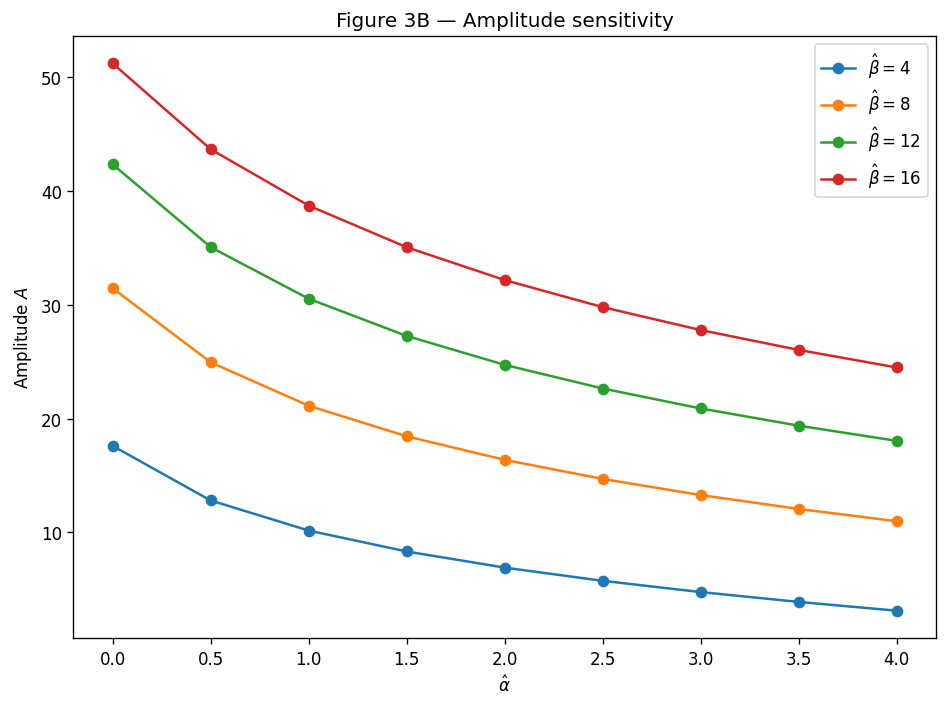

In [25]:
plt.figure(figsize=(8, 6))

for beta_value in beta_values_3:

    plt.plot(
        alpha_values_3,
        amplitude_vs_alpha[beta_value],
        marker="o",
        label=fr"$\hat\beta={beta_value:g}$"
    )

plt.xlabel(r"$\hat\alpha$")
plt.ylabel(r"Amplitude $A$")
plt.title("Figure 3B — Amplitude sensitivity")
plt.legend()
plt.tight_layout()
plt.show()

## Additional analysis — Amplitude versus cooperativity

The following sweep is an additional analysis and is not a direct reproduction of a published panel.

In [26]:
m_values_3 = np.linspace(1.0, 5.0, 9)

amplitude_vs_m = {}

for beta_value in beta_values_3:

    amplitudes = []

    for m_value in m_values_3:

        p_test = params.copy()
        p_test["alpha"] = 4.0
        p_test["beta"] = beta_value
        p_test["m"] = m_value

        if beta_value < gain_threshold(p_test):
            amplitudes.append(np.nan)
            continue

        sol = simulate_closed_loop(
            p_test,
            t_end=200,
            n_points=4000
        )

        amplitudes.append(
            steady_state_amplitude(
                sol.t,
                sol.y[3]
            )
        )

    amplitude_vs_m[beta_value] = np.array(amplitudes)

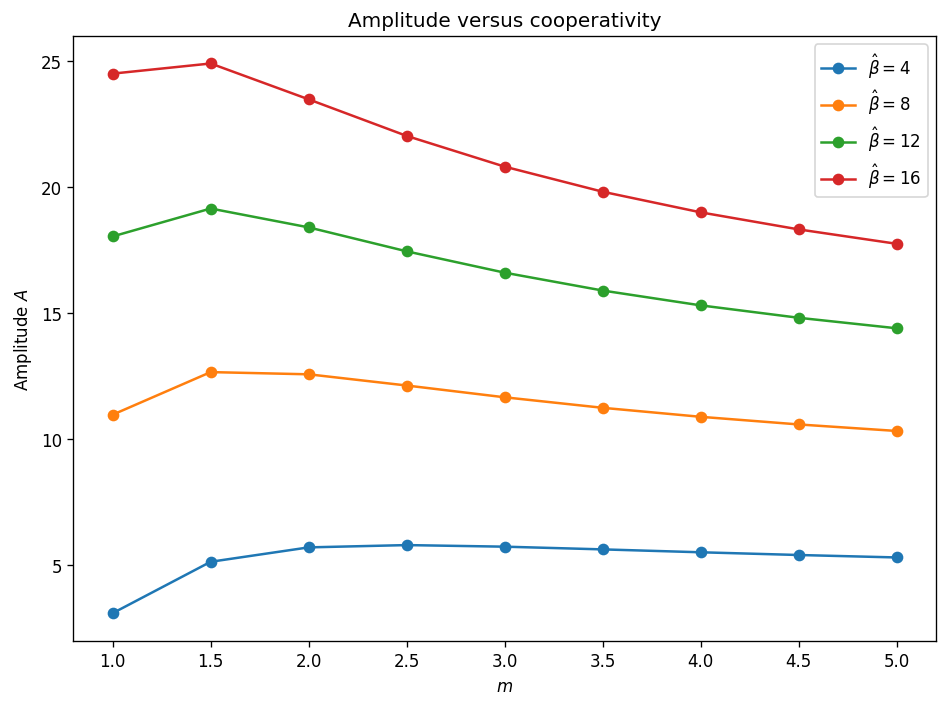

In [27]:
plt.figure(figsize=(8, 6))

for beta_value in beta_values_3:

    plt.plot(
        m_values_3,
        amplitude_vs_m[beta_value],
        marker="o",
        label=fr"$\hat\beta={beta_value:g}$"
    )

plt.xlabel(r"$m$")
plt.ylabel(r"Amplitude $A$")
plt.title("Amplitude versus cooperativity")
plt.legend()
plt.tight_layout()
plt.show()

# Figure 3C — Robustness in period

The paper defines \(T\) as the mean time between adjacent peaks.

The same four controller gains are used as in Fig. 3B.

In [28]:
period_vs_alpha = {}

for beta_value in beta_values_3:

    periods = []

    for alpha_value in alpha_values_3:

        p_test = params.copy()
        p_test["alpha"] = alpha_value
        p_test["beta"] = beta_value
        p_test["m"] = 1.0

        if beta_value < gain_threshold(p_test):
            periods.append(np.nan)
            continue

        sol = simulate_closed_loop(
            p_test,
            t_end=200,
            n_points=5000
        )

        periods.append(
            peak_period(
                sol.t,
                sol.y[3],
                start_fraction=0.5,
                min_peak_distance=100
            )
        )

    period_vs_alpha[beta_value] = np.array(periods)

In [29]:
period_vs_m = {}

for beta_value in beta_values_3:

    periods = []

    for m_value in m_values_3:

        p_test = params.copy()
        p_test["alpha"] = 4.0
        p_test["beta"] = beta_value
        p_test["m"] = m_value

        if beta_value < gain_threshold(p_test):
            periods.append(np.nan)
            continue

        sol = simulate_closed_loop(
            p_test,
            t_end=200,
            n_points=5000
        )

        periods.append(
            peak_period(
                sol.t,
                sol.y[3],
                start_fraction=0.5,
                min_peak_distance=100
            )
        )

    period_vs_m[beta_value] = np.array(periods)

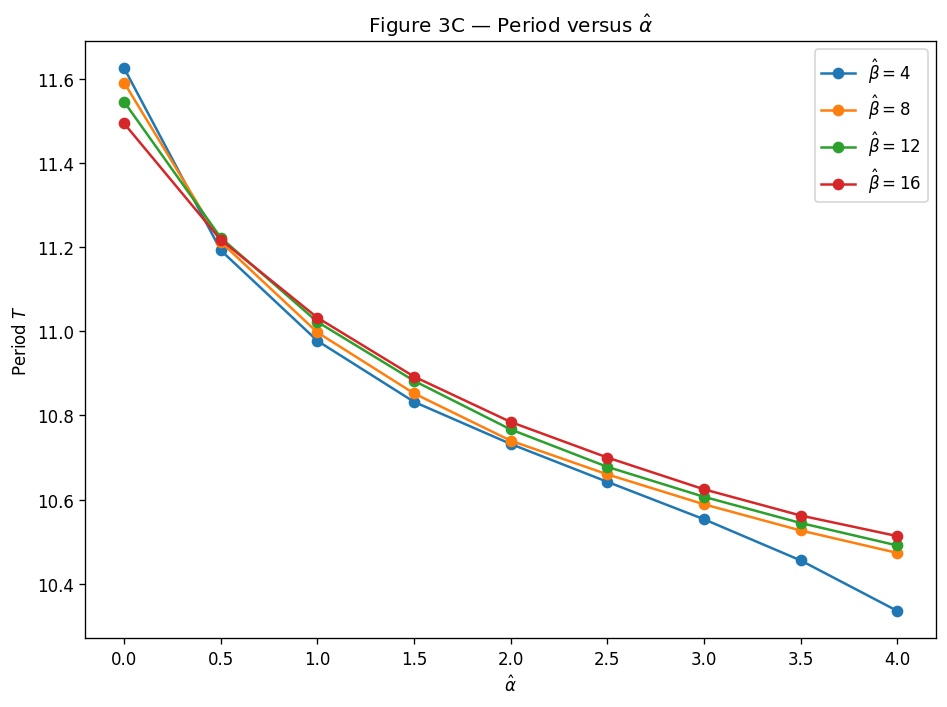

In [30]:
plt.figure(figsize=(8, 6))

for beta_value in beta_values_3:

    plt.plot(
        alpha_values_3,
        period_vs_alpha[beta_value],
        marker="o",
        label=fr"$\hat\beta={beta_value:g}$"
    )

plt.xlabel(r"$\hat\alpha$")
plt.ylabel(r"Period $T$")
plt.title(r"Figure 3C — Period versus $\hat\alpha$")
plt.legend()
plt.tight_layout()
plt.show()

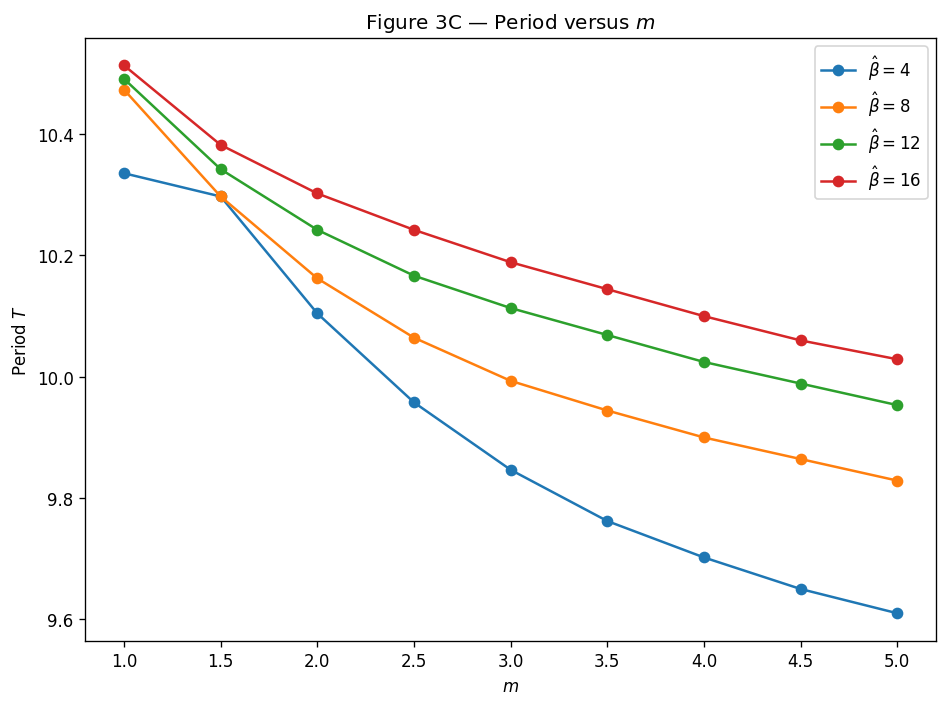

In [31]:
plt.figure(figsize=(8, 6))

for beta_value in beta_values_3:

    plt.plot(
        m_values_3,
        period_vs_m[beta_value],
        marker="o",
        label=fr"$\hat\beta={beta_value:g}$"
    )

plt.xlabel(r"$m$")
plt.ylabel(r"Period $T$")
plt.title("Figure 3C — Period versus $m$")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
def period_variation_percent(periods):
    periods = np.asarray(periods, dtype=float)
    periods = periods[np.isfinite(periods)]

    if len(periods) == 0:
        return np.nan

    mean_period = np.mean(periods)

    return (
        100.0
        * np.max(np.abs(periods - mean_period))
        / mean_period
    )


print("Maximum period variation across alpha sweeps:")

for beta_value in beta_values_3:

    variation = period_variation_percent(
        period_vs_alpha[beta_value]
    )

    print(
        f"beta={beta_value:g}: "
        f"{variation:.2f}%"
    )

Maximum period variation across alpha sweeps:
beta=4: 7.48%
beta=8: 6.84%
beta=12: 6.29%
beta=16: 5.75%


# 9. Higher-dimensional negative-feedback oscillator — Figure 4

The paper's Eq. (30) contains **seven dynamic variables**:

\[
(\hat m_z,\hat z,\hat m_y,\hat y,\hat u_1,\hat u_2,\hat x).
\]

The nominal parameters are

\[
m=4,\quad
\hat\kappa=\hat\xi=\hat\zeta=\hat\phi=1,
\]

\[
\hat k=2,\quad
\hat\gamma=100,\quad
\hat\rho=\hat k\hat\phi=2,\quad
\hat\alpha=1,
\]

with nominal \(\hat\beta=1\).

In [33]:
nf_params = {
    "alpha": 1.0,
    "beta": 1.0,
    "k": 2.0,
    "theta": 1.0,
    "rho": 2.0,
    "gamma": 100.0,
    "m": 4.0,
    "kappa": 1.0,
    "xi": 1.0,
    "zeta": 1.0,
    "phi": 1.0,
}

nf_initial_conditions = np.zeros(7)

nf_params

{'alpha': 1.0,
 'beta': 1.0,
 'k': 2.0,
 'theta': 1.0,
 'rho': 2.0,
 'gamma': 100.0,
 'm': 4.0,
 'kappa': 1.0,
 'xi': 1.0,
 'zeta': 1.0,
 'phi': 1.0}

## Eq. (30) implementation

In [34]:
def nf_closed_loop_ode(tau, state, params):

    mz, z, my, y, u1, u2, x = state

    alpha = params["alpha"]
    beta = params["beta"]
    k = params["k"]
    theta = params["theta"]
    rho = params["rho"]
    gamma = params["gamma"]
    m = params["m"]

    kappa = params["kappa"]
    xi = params["xi"]
    zeta = params["zeta"]
    phi = params["phi"]

    repression = 1.0 / (1.0 + y**m)
    activation = z**m / (1.0 + z**m)

    dmz_dt = alpha * repression - mz
    dz_dt = kappa * mz - z
    dmy_dt = xi * activation - my
    dy_dt = zeta * my - y + beta * u1

    du1_dt = k * x - phi * u1 - gamma * u1 * u2
    du2_dt = rho * repression - phi * u2 - gamma * u1 * u2
    dx_dt = theta * repression - phi * x

    return np.array([
        dmz_dt,
        dz_dt,
        dmy_dt,
        dy_dt,
        du1_dt,
        du2_dt,
        dx_dt
    ])

## Figure 4B — NF oscillator

The NF oscillator is first moved into a non-oscillatory regime by reducing production rates and cooperativity. The controller is then applied with a high gain.

The paper does not specify the exact gain used for this panel; the notebook therefore treats the high-gain simulation as a diagnostic reproduction.

In [51]:
tau_nf = np.linspace(0.0, 200.0, 5000)

nf_controlled = solve_ivp(
    fun=lambda tau, state:
        nf_closed_loop_ode(tau, state, nf_params),
    t_span=(0.0, 200.0),
    y0=nf_initial_conditions,
    t_eval=tau_nf,
    rtol=1e-8,
    atol=1e-10
)

z_c = nf_controlled.y[1]
y_c = nf_controlled.y[3]

In [52]:
def nf_uncontrolled_ode(tau, state, params):

    mz, z, my, y = state

    alpha = params["alpha"]
    m = params["m"]

    kappa = params["kappa"]
    xi = params["xi"]
    zeta = params["zeta"]

    repression = 1.0 / (1.0 + y**m)
    activation = z**m / (1.0 + z**m)

    return np.array([
        alpha * repression - mz,
        kappa * mz - z,
        xi * activation - my,
        zeta * my - y
    ])


nf_uncontrolled = solve_ivp(
    fun=lambda tau, state:
        nf_uncontrolled_ode(tau, state, nf_params),
    t_span=(0.0, 200.0),
    y0=np.zeros(4),
    t_eval=tau_nf,
    rtol=1e-8,
    atol=1e-10
)

z_u = nf_uncontrolled.y[1]
y_u = nf_uncontrolled.y[3]

In [53]:
# Parameters used to move the NF oscillator into the
# non-oscillatory regime for Figure 4B.

nf_params_4b = nf_params.copy()

# Reduce production rates by 0.5×
nf_params_4b["alpha"] *= 0.5
nf_params_4b["kappa"] *= 0.5
nf_params_4b["xi"] *= 0.5
nf_params_4b["zeta"] *= 0.5

# Reduce cooperativity: m = 4 -> 2
nf_params_4b["m"] = 2.0

# The paper states that a sufficiently high controller
# gain is required, but does not specify the exact value.
#
# Use a high-gain value only as a diagnostic reproduction.
nf_params_4b["beta"] = 32.0

nf_params_4b

{'alpha': 0.5,
 'beta': 32.0,
 'k': 2.0,
 'theta': 1.0,
 'rho': 2.0,
 'gamma': 100.0,
 'm': 2.0,
 'kappa': 0.5,
 'xi': 0.5,
 'zeta': 0.5,
 'phi': 1.0}

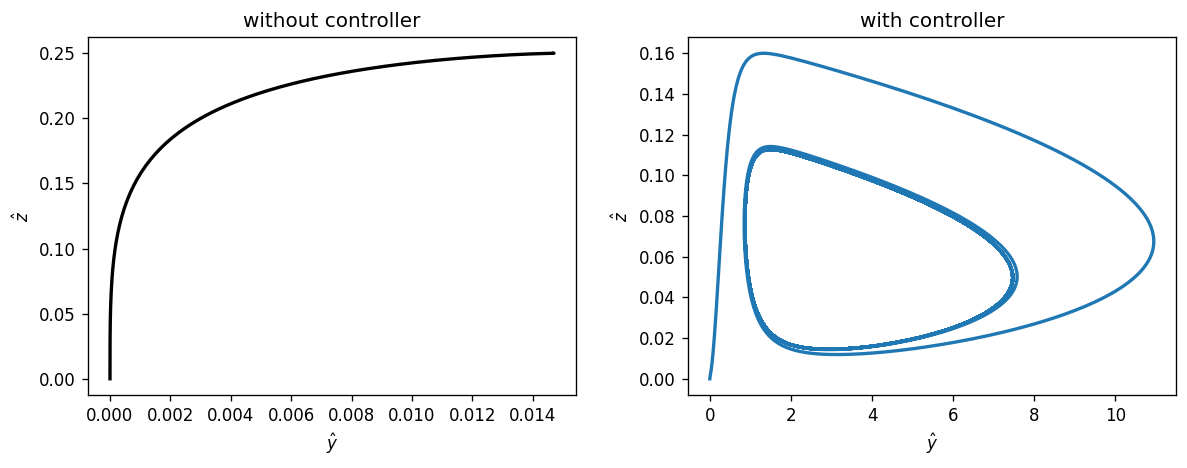

In [54]:
# Figure 4B
# Uncontrolled vs controlled NF oscillator
# after moving the process into the non-oscillatory regime.

tau_4b = np.linspace(0.0, 200.0, 5000)


# ---------------------------------------------------------
# WITHOUT CONTROLLER
# ---------------------------------------------------------

nf_uncontrolled_4b = solve_ivp(
    fun=lambda tau, state:
        nf_uncontrolled_ode(
            tau,
            state,
            nf_params_4b
        ),
    t_span=(0.0, 200.0),
    y0=np.zeros(4),
    t_eval=tau_4b,
    rtol=1e-8,
    atol=1e-10
)


# ---------------------------------------------------------
# WITH CONTROLLER
# ---------------------------------------------------------

nf_controlled_4b = solve_ivp(
    fun=lambda tau, state:
        nf_closed_loop_ode(
            tau,
            state,
            nf_params_4b
        ),
    t_span=(0.0, 200.0),
    y0=np.zeros(7),
    t_eval=tau_4b,
    rtol=1e-8,
    atol=1e-10
)


# Extract the process variables
y_u = nf_uncontrolled_4b.y[3]
z_u = nf_uncontrolled_4b.y[1]

y_c = nf_controlled_4b.y[3]
z_c = nf_controlled_4b.y[1]


# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4)
)


# Without controller
axes[0].plot(
    y_u,
    z_u,
    color="black",
    linewidth=2
)

axes[0].set_title(
    "without controller"
)

axes[0].set_xlabel(
    r"$\hat y$"
)

axes[0].set_ylabel(
    r"$\hat z$"
)


# With controller
axes[1].plot(
    y_c,
    z_c,
    linewidth=2
)

axes[1].set_title(
    "with controller"
)

axes[1].set_xlabel(
    r"$\hat y$"
)

axes[1].set_ylabel(
    r"$\hat z$"
)


plt.tight_layout()
plt.show()

## Figure 4C — Sequential perturbations

The process is perturbed at \(\tau=40,80,120\):

\[
\{\hat\alpha,\hat\kappa,\hat\xi,\hat\zeta\}\times0.5,
\qquad
m:4\rightarrow2,
\qquad
\hat\phi\times1.25.
\]

The paper contains an inconsistency: the figure annotation appears as \(m\times2\), while the caption and main text describe a decrease to \(m=2\). The implementation follows the stated \(m=2\) value.

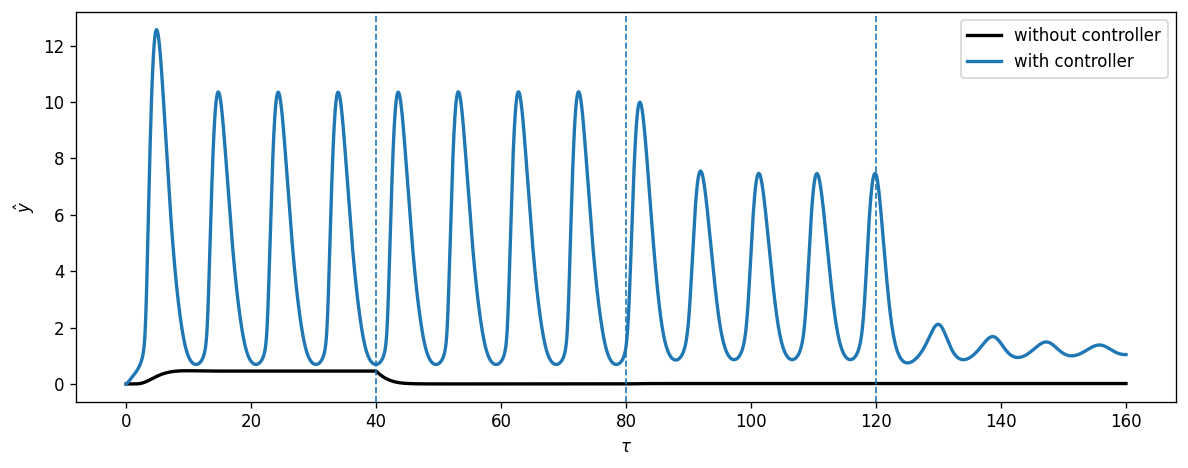

In [55]:
# Figure 4C — Sequential perturbations

beta_4c = 32.0

boundaries = [
    0.0,
    40.0,
    80.0,
    120.0,
    160.0
]


def get_stage_parameters(base_params, stage):

    p = base_params.copy()

    # High controller gain used for the diagnostic
    # high-gain reproduction.
    p["beta"] = beta_4c

    # Stage 1: nominal system
    if stage == 0:
        return p

    # Stage 2:
    # production rates × 0.5
    if stage >= 1:
        p["alpha"] *= 0.5
        p["kappa"] *= 0.5
        p["xi"] *= 0.5
        p["zeta"] *= 0.5

    # Stage 3:
    # cooperativity: m = 4 -> 2
    if stage >= 2:
        p["m"] = 2.0

    # Stage 4:
    # degradation rate × 1.25
    if stage >= 3:
        p["phi"] *= 1.25

    return p


def simulate_nf_sequential(controlled=True):

    if controlled:
        state = np.zeros(7)
        ode_function = nf_closed_loop_ode
    else:
        state = np.zeros(4)
        ode_function = nf_uncontrolled_ode

    all_t = []
    all_states = []

    for stage in range(4):

        p_stage = get_stage_parameters(
            nf_params,
            stage
        )

        t0 = boundaries[stage]
        t1 = boundaries[stage + 1]

        t_eval = np.linspace(
            t0,
            t1,
            1000
        )

        solution = solve_ivp(
            fun=lambda tau, state:
                ode_function(
                    tau,
                    state,
                    p_stage
                ),
            t_span=(t0, t1),
            y0=state,
            t_eval=t_eval,
            rtol=1e-8,
            atol=1e-10
        )

        if stage == 0:

            all_t.extend(
                solution.t
            )

            all_states.extend(
                solution.y.T
            )

        else:

            all_t.extend(
                solution.t[1:]
            )

            all_states.extend(
                solution.y[:, 1:].T
            )

        state = solution.y[:, -1]

    return (
        np.asarray(all_t),
        np.asarray(all_states)
    )


# Run uncontrolled system
tau_4c_u, states_4c_u = (
    simulate_nf_sequential(
        controlled=False
    )
)


# Run controlled system
tau_4c_c, states_4c_c = (
    simulate_nf_sequential(
        controlled=True
    )
)


# Extract y
y_4c_u = states_4c_u[:, 3]
y_4c_c = states_4c_c[:, 3]


# Plot
plt.figure(figsize=(10, 4))

plt.plot(
    tau_4c_u,
    y_4c_u,
    color="black",
    linewidth=2,
    label="without controller"
)

plt.plot(
    tau_4c_c,
    y_4c_c,
    linewidth=2,
    label="with controller"
)


# Perturbation boundaries
for t in [40, 80, 120]:

    plt.axvline(
        t,
        linestyle="--",
        linewidth=1
    )


plt.xlabel(r"$\tau$")
plt.ylabel(r"$\hat y$")

plt.legend()

plt.tight_layout()
plt.show()

In [56]:
def simulate_nf_uncontrolled_sequential(
    base_params,
    perturbation_times=(40, 80, 120),
    final_time=160,
    points_per_interval=1200
):
    boundaries = [0.0, *perturbation_times, final_time]

    state = np.zeros(4)
    all_t = []
    all_states = []

    for i in range(4):

        p = base_params.copy()

        if i >= 1:
            p["alpha"] *= 0.5
            p["kappa"] *= 0.5
            p["xi"] *= 0.5
            p["zeta"] *= 0.5

        if i >= 2:
            p["m"] = 2.0

        if i >= 3:
            p["phi"] *= 1.25

        t0 = boundaries[i]
        t1 = boundaries[i + 1]

        t_eval = np.linspace(t0, t1, points_per_interval)

        sol = solve_ivp(
            fun=lambda tau, state:
                nf_uncontrolled_ode(tau, state, p),
            t_span=(t0, t1),
            y0=state,
            t_eval=t_eval,
            rtol=1e-8,
            atol=1e-10
        )

        if i == 0:
            all_t.extend(sol.t)
            all_states.extend(sol.y.T)
        else:
            all_t.extend(sol.t[1:])
            all_states.extend(sol.y[:, 1:].T)

        state = sol.y[:, -1]

    return np.array(all_t), np.array(all_states)

## Figure 4D — Period versus \(\hat\alpha\)

The oscillation period is evaluated across:

\[
\hat\alpha\in[0,4],
\qquad
\hat\beta=\{1,2,3,4\}.
\]

Period is estimated from successive peaks of \(\hat y\).

In [49]:
def peak_period_safe(t, signal, start_fraction=0.5, min_peak_distance=100):

    start_idx = int(len(t) * start_fraction)

    t_ss = t[start_idx:]
    y_ss = signal[start_idx:]

    peaks, _ = find_peaks(
        y_ss,
        distance=min_peak_distance
    )

    if len(peaks) < 3:
        return np.nan

    peak_times = t_ss[peaks]

    periods = np.diff(peak_times)

    return np.mean(periods)

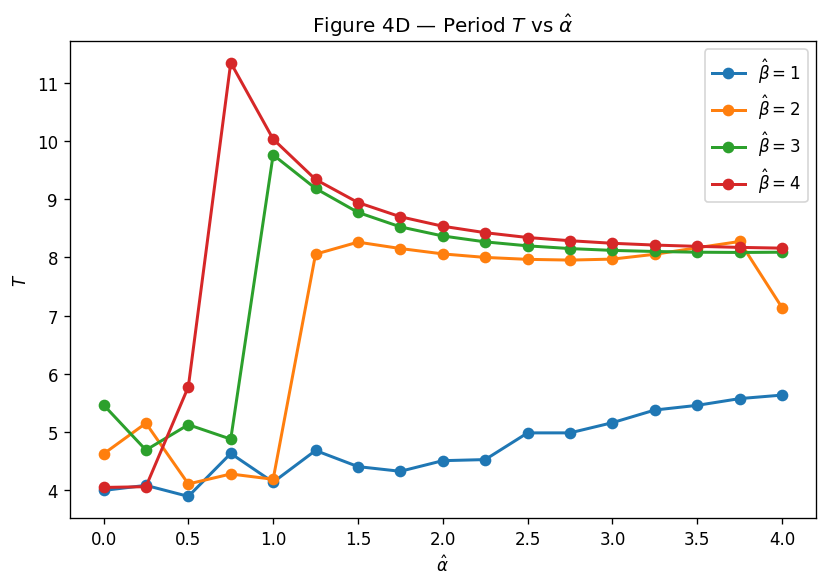

In [50]:
# Figure 4D — Period T vs alpha for increasing beta

alpha_values_4d = np.linspace(0.0, 4.0, 17)
beta_values_4d = [1.0, 2.0, 3.0, 4.0]

period_vs_alpha_4d = {
    beta: [] for beta in beta_values_4d
}

# Simulation settings
t_start = 0.0
t_end = 300.0
n_points = 8000

tau_4d = np.linspace(
    t_start,
    t_end,
    n_points
)


for beta_value in beta_values_4d:

    for alpha_value in alpha_values_4d:

        # Start from the nominal Eq. (30) parameter set
        p = nf_params.copy()

        p["alpha"] = alpha_value
        p["beta"] = beta_value

        # Simulate controlled NF oscillator
        sol = solve_ivp(
            fun=lambda tau, state:
                nf_closed_loop_ode(
                    tau,
                    state,
                    p
                ),
            t_span=(t_start, t_end),
            y0=np.zeros(7),
            t_eval=tau_4d,
            rtol=1e-8,
            atol=1e-10
        )

        # Process output y_hat
        y = sol.y[3]

        # Estimate period after transient
        T = peak_period_safe(
            sol.t,
            y,
            start_fraction=0.5,
            min_peak_distance=100
        )

        period_vs_alpha_4d[beta_value].append(T)


# Convert lists to arrays
for beta_value in beta_values_4d:
    period_vs_alpha_4d[beta_value] = np.asarray(
        period_vs_alpha_4d[beta_value]
    )


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

plt.figure(figsize=(7, 5))

for beta_value in beta_values_4d:

    plt.plot(
        alpha_values_4d,
        period_vs_alpha_4d[beta_value],
        marker="o",
        linewidth=1.8,
        label=rf"$\hat{{\beta}}={beta_value:g}$"
    )

plt.xlabel(r"$\hat{\alpha}$")
plt.ylabel(r"$T$")

plt.title(
    r"Figure 4D — Period $T$ vs $\hat{\alpha}$"
)

plt.legend()

plt.tight_layout()
plt.show()

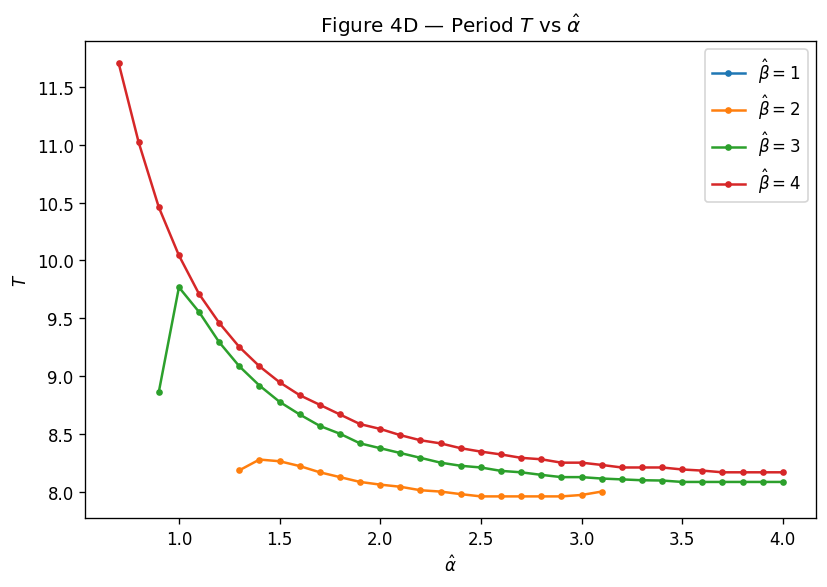

In [57]:
# ============================================================
# Figure 4D — Period T vs alpha for increasing beta
# ============================================================

alpha_values = np.linspace(0.1, 4.0, 40)
beta_values = [1.0, 2.0, 3.0, 4.0]

t_end = 500.0
n_points = 12000
t_eval = np.linspace(0.0, t_end, n_points)


def estimate_period(t, y, transient_fraction=0.7):
    """
    Estimate period from the mean spacing between
    successive peaks after the transient.
    """

    start = int(len(t) * transient_fraction)

    t_ss = t[start:]
    y_ss = y[start:]

    peaks, _ = find_peaks(
        y_ss,
        distance=100,
        prominence=0.05
    )

    # Need enough peaks for a reliable estimate
    if len(peaks) < 4:
        return np.nan

    peak_times = t_ss[peaks]

    periods = np.diff(peak_times)

    # Remove obvious numerical/outlier intervals
    if len(periods) >= 5:
        q1 = np.percentile(periods, 25)
        q3 = np.percentile(periods, 75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        periods = periods[
            (periods >= lower) &
            (periods <= upper)
        ]

    if len(periods) == 0:
        return np.nan

    return np.mean(periods)


period_vs_alpha = {}

for beta_value in beta_values:

    periods = []

    for alpha_value in alpha_values:

        # Start from the NOMINAL Eq. (30) parameters
        p = nf_params.copy()

        p["alpha"] = alpha_value
        p["beta"] = beta_value

        # Numerical simulation
        sol = solve_ivp(
            fun=lambda tau, state:
                nf_closed_loop_ode(
                    tau,
                    state,
                    p
                ),
            t_span=(0.0, t_end),
            y0=np.zeros(7),
            t_eval=t_eval,
            method="RK45",
            rtol=1e-8,
            atol=1e-10
        )

        y = sol.y[3]

        T = estimate_period(
            sol.t,
            y,
            transient_fraction=0.7
        )

        periods.append(T)

    period_vs_alpha[beta_value] = np.array(periods)


# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(7, 5))

for beta_value in beta_values:

    plt.plot(
        alpha_values,
        period_vs_alpha[beta_value],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=rf"$\hat{{\beta}}={beta_value:g}$"
    )

plt.xlabel(r"$\hat{\alpha}$")
plt.ylabel(r"$T$")

plt.title(
    r"Figure 4D — Period $T$ vs $\hat{\alpha}$"
)

plt.legend()

plt.tight_layout()
plt.show()

# 10. Reproduction summary

The main numerical conclusions to check against the paper are:

- the isolated self-inhibiting gene approaches a fixed point;
- the IFFL-controlled system develops sustained oscillations;
- the numerical stability boundary broadly follows Eq. (27);
- sustained oscillations occur in the reported \(\hat r\le1\) regime;
- sufficiently weak sequestration produces damped rather than sustained oscillations;
- amplitude is more sensitive to parameter perturbations than period;
- the controller rescues oscillations in the higher-dimensional NF oscillator.

> **Reproduction note**
>
> The published text states that a sufficiently high controller gain is required for the rescue experiment, while the Fig. 4 caption lists the nominal value \(\hat\beta=1\).
>
> The exact gain used specifically for Panels B–C is therefore not fully specified in the published description. I retain the published nominal value rather than introducing an undocumented gain.